In [1]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

# Deep Neural Networks 
## Session 08a

## Working with Tensorflow 
- One hidden layer
- ${ReLU}$ activation function
- Adam
- Multi-class output
- FIFA dataset

<img src='../../prasami_images/prasami_color_tutorials_small.png' width='400' alt="By Pramod Sharma : pramod.sharma@prasami.com" align="left"/>

In [2]:
###-----------------
### Import Libraries
###-----------------

from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
from time import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, f1_score
from sklearn.preprocessing import StandardScaler

import tensorflow as tf

In [3]:
###----------------------
### Some basic parameters
###----------------------

inpDir = Path('../../input') # location where input data is stored
outDir = Path('../output') # location to store outputs
modelDir = Path('../models') # location of the images
subDir = 'WEATHER '

RANDOM_STATE = 24 # for initialization ----- REMEMBER: to remove at the time of promotion to production
np.random.seed(RANDOM_STATE) # Set Random Seed for reproducible  results
#tf.random.set_seed(RANDOM_STATE) # setting for Tensorflow as well


EPOCHS = 30 # number of epochs
ALPHA = 0.001 # learning rate
BATCH_SIZE = 32
TEST_SIZE = 0.2
TIME_STEPS=24


# Set parameters for decoration of plots
params = {'legend.fontsize' : 'large',
          'figure.figsize'  : (15,15),
          'axes.labelsize'  : 'x-large',
          'axes.titlesize'  :'x-large',
          'xtick.labelsize' :'large',
          'ytick.labelsize' :'large',
         }

CMAP = plt.cm.coolwarm

plt.rcParams.update(params) # update rcParams

plt.style.use('seaborn-v0_8-darkgrid') # plt.style.use('ggplot')

## Basic Hygiene

In [4]:
# Check if all directories are present
if not inpDir.exists: # input directory
    print ('Directory {} does not exist!'.format(inpDir))

if not modelDir.exists: # models directory
    print ('Directory {} does not exist!'.format(modelDir))

if not outDir.exists: # output dir
    print ('Directory {} does not exist!'.format(outDir))

model_location = modelDir/subDir
if not model_location.exists:
    model_location.mkdir(parents=True, exist_ok=True)
    print ('Created {} directory'.format(os.path.join(modelDir, subDir)))
    

## Read weather history data set

In [5]:
data_df = pd.read_csv('D:/Deep_Learning/SharedData/weatherHistory.csv')

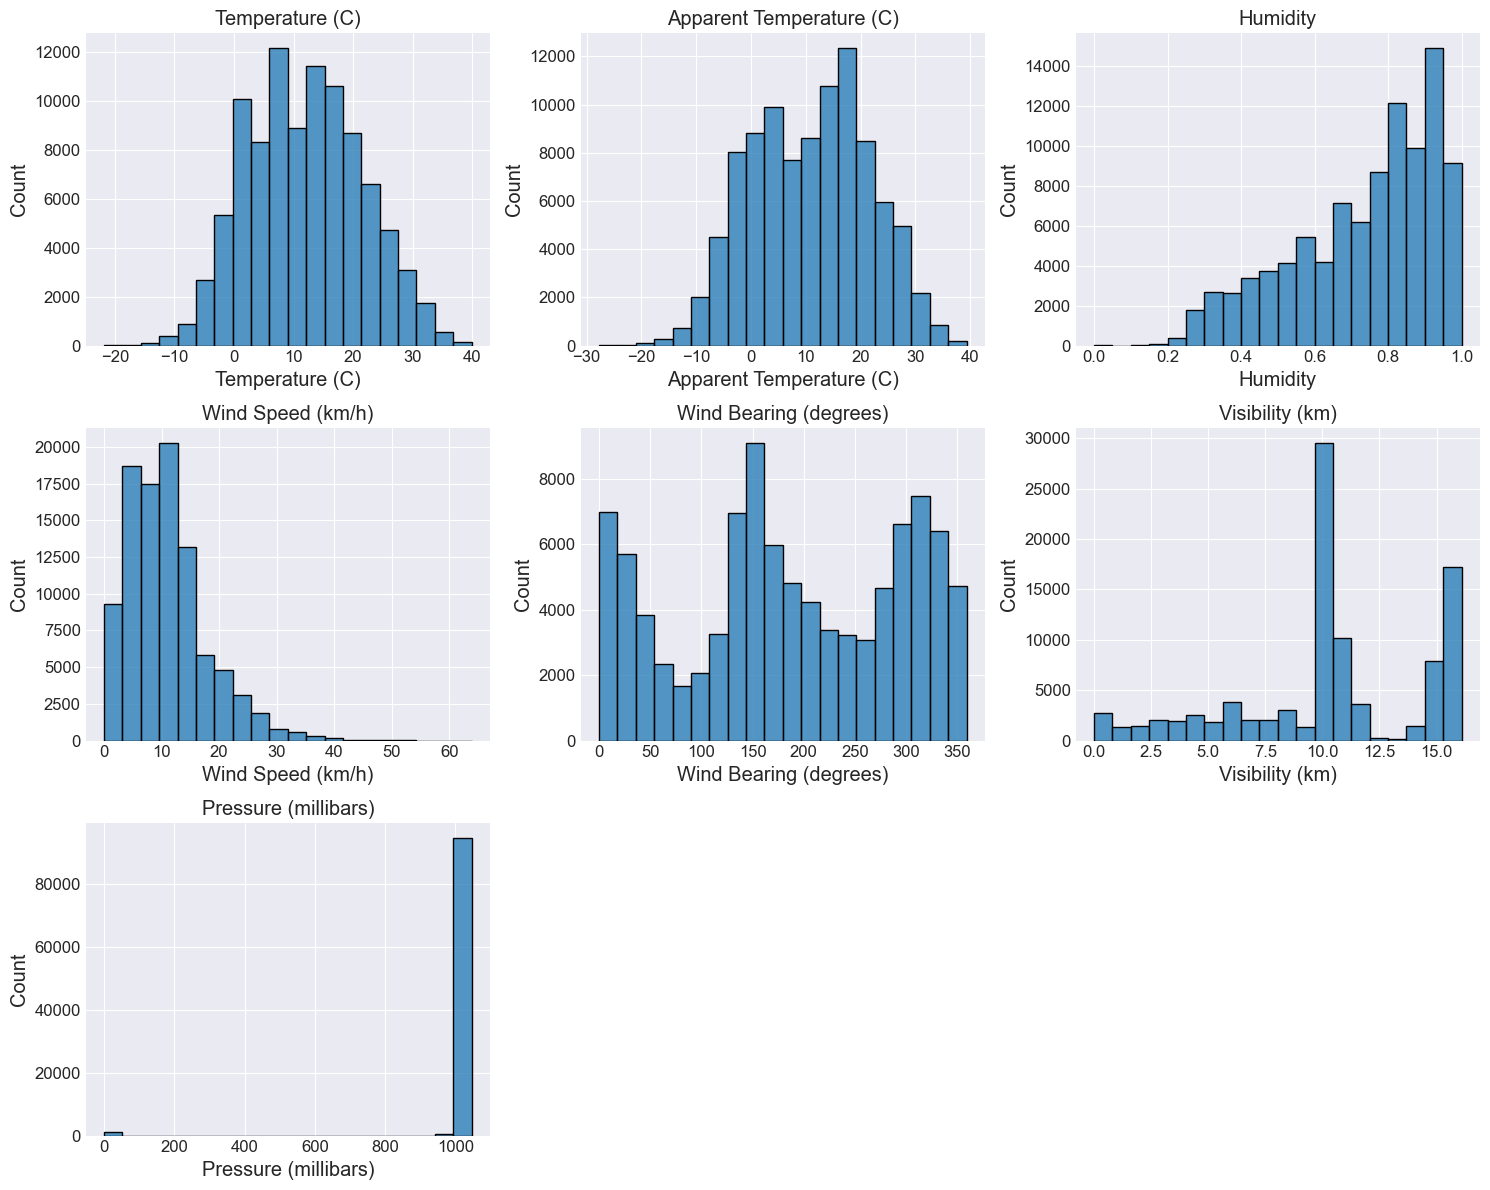

In [6]:


# Define target numerical columns
num_cols = [
    'Temperature (C)', 
    'Apparent Temperature (C)', 
    'Humidity', 
    'Wind Speed (km/h)', 
    'Wind Bearing (degrees)', 
    'Visibility (km)', 
    'Pressure (millibars)'
]

# Expand grid to 3x3 (9 slots) to fit all 7 features safely
fig, axes = plt.subplots(3, 3, figsize=(15, 12)) 
axes = axes.ravel()

# Fixed Loop: Safely unpacking index and column name directly
for i, col_name in enumerate(num_cols):
    ax = axes[i]
    sns.histplot(data=data_df, x=col_name, ax=ax, bins=20)
    ax.set_title(col_name) # Added titles for better readability

# Hide the remaining 2 empty subplots
for j in range(len(num_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()




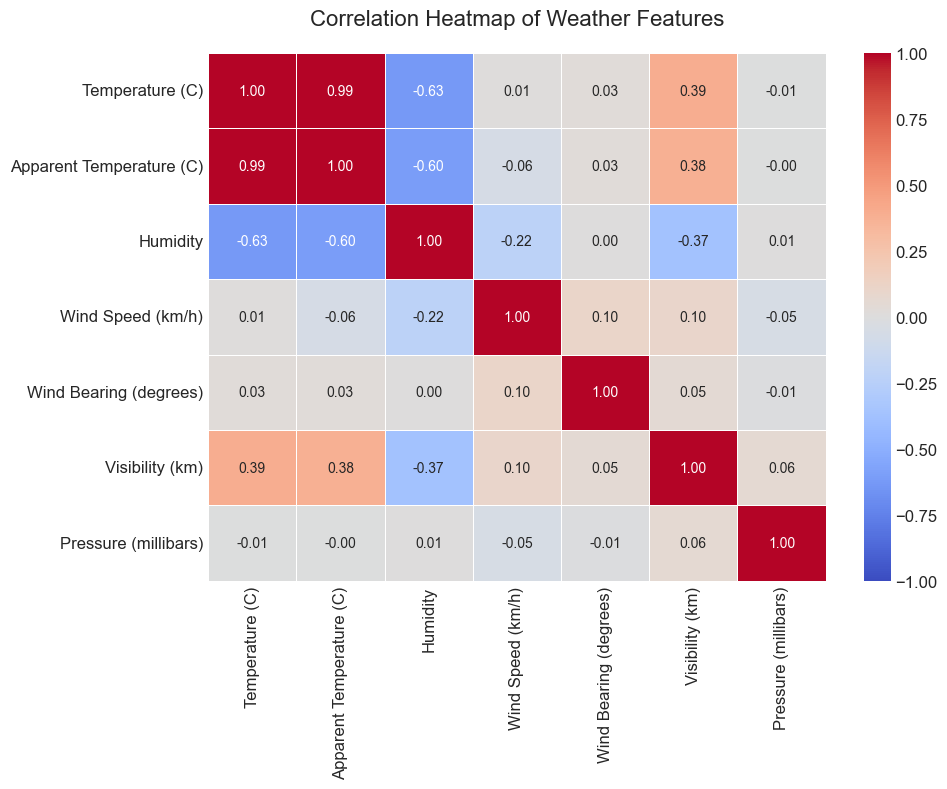

In [7]:
# -------------------------------------------------------------
# 1. GENERATE THE CORRELATION HEATMAP
# -------------------------------------------------------------
# Calculate the correlation matrix for the numerical features
corr_matrix = data_df[num_cols].corr()

# Create a figure specifically for the heatmap
plt.figure(figsize=(10, 8))
plt.title('Correlation Heatmap of Weather Features', fontsize=16, pad=20)

# Draw the heatmap
sns.heatmap(
    corr_matrix, 
    annot=True,          # Displays the correlation numbers inside the squares
    cmap='coolwarm',     # Uses your CMAP variable structure
    fmt=".2f",           # Rounds numbers to 2 decimal places
    linewidths=0.5,      # Adds subtle lines between squares
    vmin=-1, vmax=1      # Fixes the scale bounds between -1 and 1
)
plt.tight_layout()
plt.show()



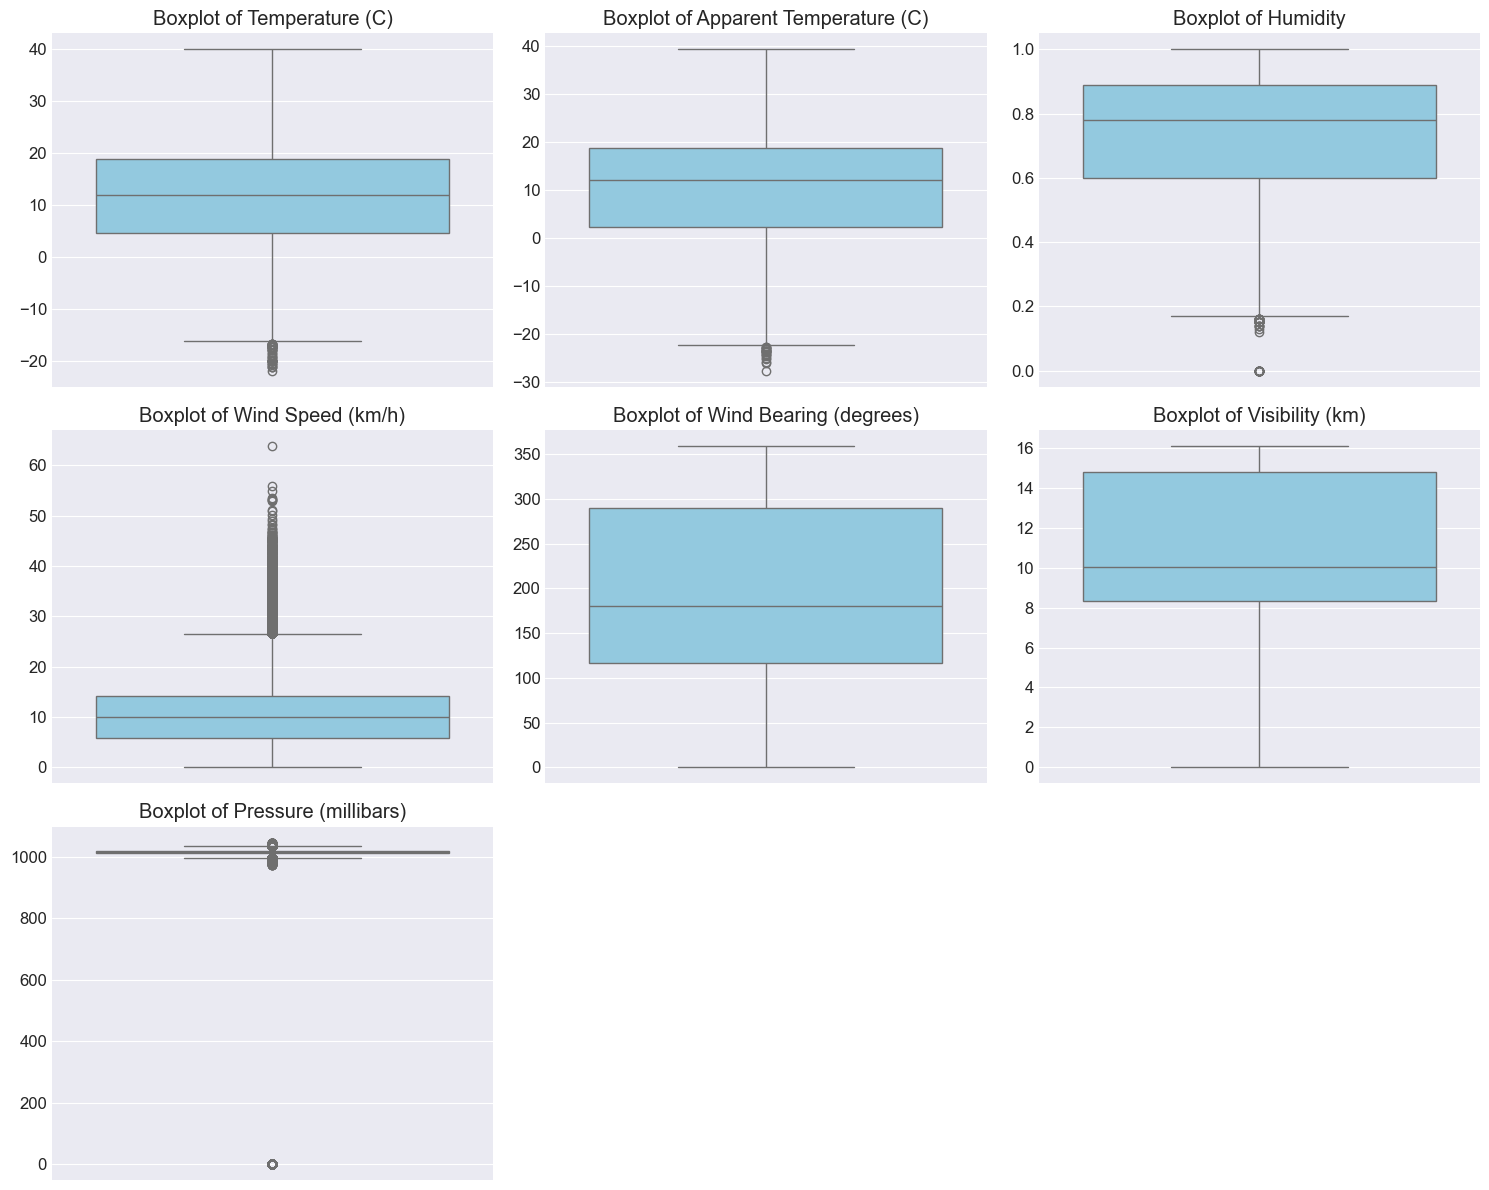

In [8]:
# -------------------------------------------------------------
# 2. GENERATE THE BOXPLOTS GRID
# -------------------------------------------------------------
# Create a subplots grid (3x3) to accommodate all 7 features
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

# Loop through columns and plot individual boxplots
for i, col_name in enumerate(num_cols):
    ax = axes[i]
    sns.boxplot(data=data_df, y=col_name, ax=ax, color='skyblue')
    ax.set_title(f'Boxplot of {col_name}')
    ax.set_ylabel('') # Clear default label to keep titles clean

# Hide the remaining 2 empty subplots
for j in range(len(num_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()



In [9]:
# Are there NaNs Still?

data_df.isna().sum()

Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64

In [10]:
data_df['datetime'] = pd.to_datetime(data_df['Formatted Date'], utc=True)
data_df.head()


,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary,datetime
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.,2006-03-31 22:00:00+00:00
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.,2006-03-31 23:00:00+00:00
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.,2006-04-01 00:00:00+00:00
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.,2006-04-01 01:00:00+00:00
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.,2006-04-01 02:00:00+00:00


In [11]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype              
---  ------                    --------------  -----              
 0   Formatted Date            96453 non-null  object             
 1   Summary                   96453 non-null  object             
 2   Precip Type               95936 non-null  object             
 3   Temperature (C)           96453 non-null  float64            
 4   Apparent Temperature (C)  96453 non-null  float64            
 5   Humidity                  96453 non-null  float64            
 6   Wind Speed (km/h)         96453 non-null  float64            
 7   Wind Bearing (degrees)    96453 non-null  float64            
 8   Visibility (km)           96453 non-null  float64            
 9   Loud Cover                96453 non-null  float64            
 10  Pressure (millibars)      96453 non-null  float64            
 11  Daily Summary  

In [12]:
temp_df = data_df[['Temperature (C)', 'Humidity', 'datetime']].copy()
temp_df = temp_df.rename({'Temperature (C)': 'temp', 'Humidity': 'hum'}, axis=1)
temp_df = temp_df.reset_index(drop=True)
temp_df.head()

,temp,hum,datetime
0,9.472222,0.89,2006-03-31 22:00:00+00:00
1,9.355556,0.86,2006-03-31 23:00:00+00:00
2,9.377778,0.89,2006-04-01 00:00:00+00:00
3,8.288889,0.83,2006-04-01 01:00:00+00:00
4,8.755556,0.83,2006-04-01 02:00:00+00:00


In [20]:
X, y = [], []
feature_cols = ['temp', 'hum']

for i in range(0, len(temp_df) - TIME_STEPS, TIME_STEPS):
    X.append(temp_df.iloc[i: i + TIME_STEPS] [feature_cols].to_numpy() )
    y.append(temp_df.iloc[i + TIME_STEPS] ['temp'])
X_data = np.array(X)

X_data = X_data[:, :-1, :]
y_data = np.array(y)
X_data.shape, y_data.shape

((4018, 23, 2), (4018,))

Text(0.5, 0, 'DateTime')

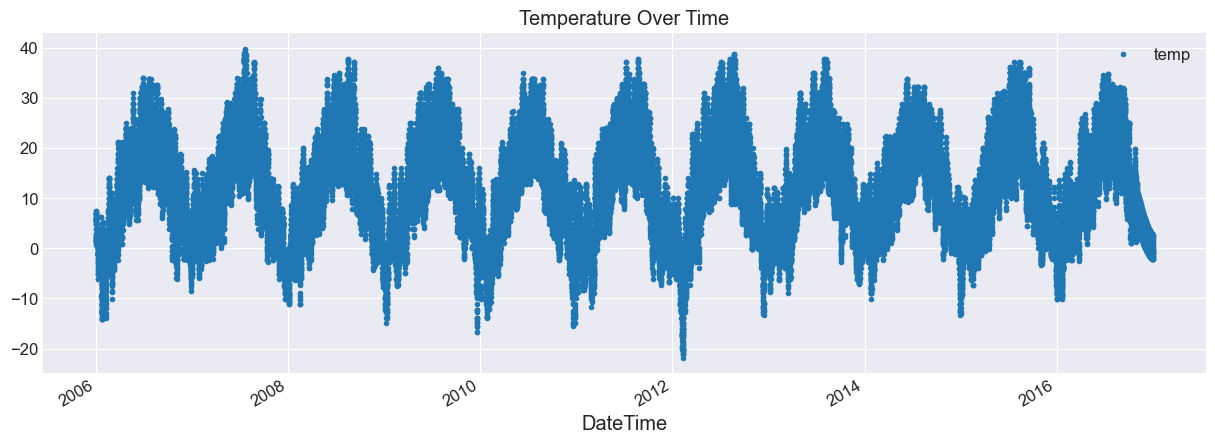

In [13]:
temp_df.plot(x='datetime', y='temp', figsize=(15, 5), title='Temperature Over Time', style='.');
plt.xlabel('DateTime')

In [14]:
h_units = 100
input_shape = (1, 10000)

model = tf.keras.Sequential()

model.add(tf.keras.layers.Input(shape = input_shape))
model.add(tf.keras.layers.SimpleRNN(units = h_units, activation ='tanh'))
model.add(tf.keras.layers.Dense(1, activation ='linear'))

In [15]:
len(model.get_weights())

5

In [16]:
data_df.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary,datetime
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.,2006-03-31 22:00:00+00:00
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.,2006-03-31 23:00:00+00:00
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.,2006-04-01 00:00:00+00:00
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.,2006-04-01 01:00:00+00:00
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.,2006-04-01 02:00:00+00:00


In [17]:
temp_df.tail()

,temp,hum,datetime
96448,26.016667,0.43,2016-09-09 17:00:00+00:00
96449,24.583333,0.48,2016-09-09 18:00:00+00:00
96450,22.038889,0.56,2016-09-09 19:00:00+00:00
96451,21.522222,0.60,2016-09-09 20:00:00+00:00
96452,20.438889,0.61,2016-09-09 21:00:00+00:00


In [18]:
X_df=temp_df.iloc[:len(y_df)*TIME_STEPS].copy()
X_df.shape, y_df.shape

NameError: name 'y_df' is not defined

In [ ]:
X =X_df['temp'].to_numpy().reshape(len(y_df), TIME_STEPS)
X.shape

(4018, 24)

In [ ]:
X=X[:,:TIME_STEPS-1]
X.shape

(4018, 23)

In [ ]:
4018*0.8

3214.4

In [ ]:
y=y_df['temp'].to_numpy()
y

array([10.42222222, 13.77222222,  8.2       , ..., 17.2       ,
       15.48888889, 15.59444444], shape=(4018,))

In [ ]:
split_idx=int(len(X)*(1-TEST_SIZE))
split_idx=split_idx//BATCH_SIZE*BATCH_SIZE
split_idx

3200

In [ ]:
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((3200, 23), (818, 23), (3200,), (818,))

In [ ]:
n_features = X_train.shape[2]
X_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_2d = X_train.reshape(-1, n_features)
X_test_2d = X_test.reshape(-1, n_features)

X_train_scaled = X_scaler.fit_transform(X_train_2d)
X_test_scaled = X_scaler.transform(X_test_2d)


X_train = X_train_scaled.reshape(X_train.shape)
X_test = X_test_scaled.reshape(X_test.shape)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((3200, 23), (818, 23), (3200,), (818,))

Preprocessing and Batching

In [ ]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

Define Model

In [ ]:
import tensorflow as tf
from sklearn.metrics import log_loss

h_units = 64
kernel_initializer = tf.keras.initializers.GlorotUniform(seed=RANDOM_STATE)
optimizer = 'adam'
loss_fn = 'mean_squared_error'

input_shape = (TIME_STEPS-1, 1) 

model = tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=input_shape))
model.add(tf.keras.layers.SimpleRNN(units=h_units, activation='tanh', kernel_initializer=kernel_initializer))
model.add(tf.keras.layers.Dense(1, activation='linear', kernel_initializer=kernel_initializer))

In [ ]:
loss.df=pd.DataFrame()

In [ ]:
y_train_pred_scaled = model.predict(X_train)
y_test_pred_scaled = model.predict(X_test)

y_pred_train = y_scaler.inverse_transform(y_train_pred_scaled.reshape(-1, 1)).flatten()
y_pred_test = y_scaler.inverse_transform(y_test_pred_scaled.reshape(-1, 1)).flatten()

y_pred = np.concatenate([y_pred_train, y_pred_test])

In [ ]:
res_df=y_df.copy()
res_df['pred'] = y_pred
res_df['datetime'] = res_df['datetime'].dt.date
res_df.plot(x='datetime', y=['temp', 'pred'])

In [ ]:
#  Split the data in training and test sets to measure performance of the model.
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=TEST_SIZE,
                                                    stratify=y,
                                                    random_state=RANDOM_STATE )

print (X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(14517, 33) (14517,) (3630, 33) (3630,)


### Normalization in Tensorflow

In [ ]:
# Create normalization layer
normalizer = tf.keras.layers.Normalization(axis=-1)

# Adapt to training data (learn mean and variance)
normalizer.adapt(X_train)  # X_train as numpy array or tensor

I0000 00:00:1778075744.814477   38464 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3808 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [ ]:
normalizer.mean.numpy(), normalizer.variance.numpy()

(array([[45.520493, 52.243782, 58.685886, 42.902115, 55.379074, 47.15747 ,
         42.83013 , 52.761726, 58.392986, 64.649925, 64.79913 , 63.53792 ,
         61.809742, 63.964455, 55.430115, 65.06902 , 63.24902 , 65.372665,
         47.119926, 55.8727  , 46.72701 , 49.943306, 53.40263 , 48.518635,
         58.645657, 47.280293, 47.679203, 45.641525, 16.618792, 16.377558,
         16.216711, 16.372667, 16.711098]], dtype=float32),
 array([[381.27637, 302.225  , 216.46509, 314.4344 , 358.05862, 338.72565,
         305.6274 , 233.78761, 277.84177, 220.56754, 213.31131, 217.05934,
          81.14435, 199.90918, 297.45694, 139.75758, 252.52716, 157.12006,
         371.17862, 301.67438, 426.03412, 381.6611 , 201.29845, 245.74033,
         130.18896, 396.54602, 468.74197, 451.3309 , 312.67398, 285.4781 ,
         271.2175 , 288.47983, 321.72186]], dtype=float32))

## Converting to Datasets
TensorFlow Dataset Pipeline Benefits:
1. from_tensor_slices() - Creates dataset from in-memory data
2. shuffle() - Randomizes order (prevents overfitting to sequence)
3. batch() - Groups samples for efficient processing
4. cache() - Stores dataset in memory after first epoch
5. prefetch() - Overlaps data preprocessing with model execution

This pipeline is ~3-5x faster than manual batching with NumPy!

In [ ]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train,y_train))
test_ds = tf.data.Dataset.from_tensor_slices((X_test,y_test))

In [ ]:
type(train_ds)

tensorflow.python.data.ops.from_tensor_slices_op._TensorSliceDataset

### Preprocessing and Batching

Apply various transformations, such as shuffling and batching, to the dataset:

In [ ]:
## Optimize for performance

train_ds = train_ds.cache()  # Cache first
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

test_ds = test_ds.cache()
test_ds = test_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

In [ ]:
# Shuffle and batch the dataset
train_ds = train_ds.shuffle(buffer_size=X_train.shape[0]).batch(BATCH_SIZE)
test_ds = test_ds.shuffle(buffer_size=X_test.shape[0]).batch(BATCH_SIZE)

In [ ]:
for features, labels in train_ds.take(1):
    print (features.shape, labels.shape)

(32, 33) (32,)


## Prepare model

### Functional API

<p style="font-family: Arial; font-size:1.2em;">You can also instantiate a Model with the <strong>"Functional API"</strong>, where you start from Input, you chain layer calls to specify the model's forward pass, and finally you create your model from inputs and outputs:

In [ ]:
inputs = tf.keras.Input(shape=(33,))

x = normalizer(inputs)
    
x = tf.keras.layers.Dense(16, activation=tf.nn.relu)(x)

x = tf.keras.layers.Dense(8, activation=tf.nn.relu)(x)

outputs = tf.keras.layers.Dense(4)(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

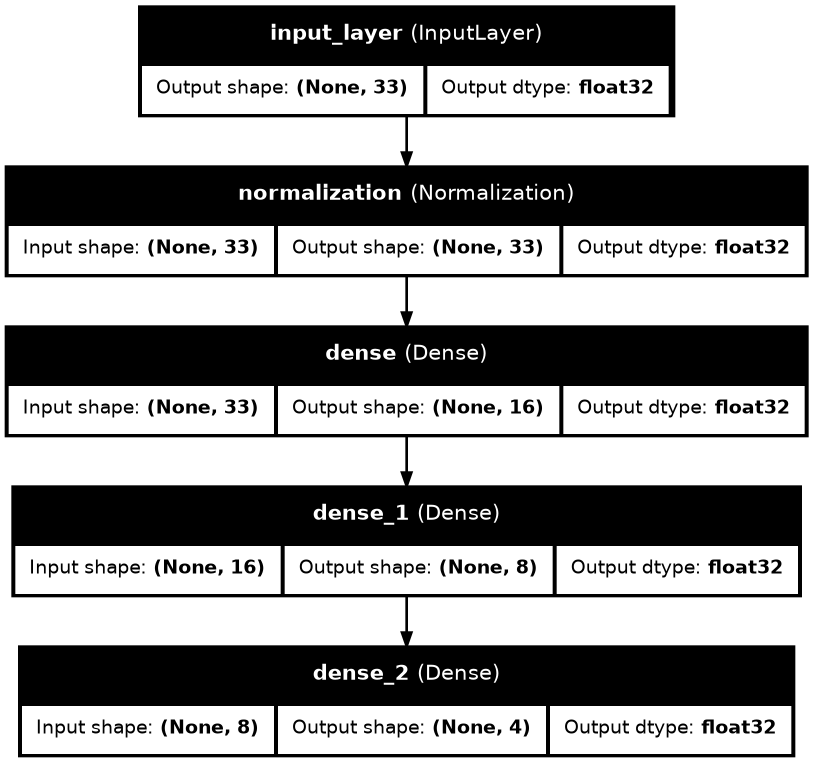

In [ ]:
tf.keras.utils.plot_model(
    model,
    to_file=outDir / 'FIFA_tf.png',
    show_shapes=True,           # Show input/output shapes
    show_dtype=True,            # Show data types
    show_layer_names=True,      # Show layer names
    expand_nested=True,         # Expand nested models
    dpi=96                      # Resolution
)


In [ ]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy ( from_logits = True)

Using `model.compile`, specify the training configuration such as:
- Loss function to minimize
- Optimizer
- List of metrics to monitor

In [ ]:
model.compile(optimizer='adam',
              loss=loss_fn,
              metrics=['accuracy'])

Call `fit()`, which will train the model by slicing the data into `batches` of size `batch_size`, and repeatedly iterating over the entire dataset for a given number of `epochs`. Pass some validation for monitoring validation loss and metrics at the end of each epoch.

In [ ]:
history = model.fit(train_ds, 
                    validation_data=test_ds,
                    batch_size=BATCH_SIZE,
                    epochs=EPOCHS)

Epoch 1/100


I0000 00:00:1778075747.394807   38563 service.cc:153] XLA service 0x78ad280324f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778075747.394829   38563 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060 Laptop GPU, Compute Capability 8.6 (Driver: 13.0.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.10.2)
I0000 00:00:1778075747.409979   38563 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778075747.512488   38563 cuda_dnn.cc:461] Loaded cuDNN version 91002
I0000 00:00:1778075747.517669   38563 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1253__.11


147/454 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2338 - loss: 1.5689

I0000 00:00:1778075749.052848   38563 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


441/454 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4755 - loss: 1.1812

I0000 00:00:1778075749.624423   38562 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1253__.11


454/454 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.6878 - loss: 0.7854 - val_accuracy: 0.8223 - val_loss: 0.4013
Epoch 2/100
454/454 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8555 - loss: 0.3542 - val_accuracy: 0.8529 - val_loss: 0.3357
Epoch 3/100
454/454 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8693 - loss: 0.3207 - val_accuracy: 0.8623 - val_loss: 0.3186
Epoch 4/100
454/454 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8759 - loss: 0.3094 - val_accuracy: 0.8625 - val_loss: 0.3089
Epoch 5/100
454/454 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8781 - loss: 0.3006 - val_accuracy: 0.8620 - val_loss: 0.3088
Epoch 6/100
454/454 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8792 - loss: 0.2958 - val_accuracy: 0.8683 - val_loss: 0.3056
Epoch 7/100
454/454 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8797 - loss: 0.2929 - val_accuracy: 0.8683 - val_loss: 0.3017
Epoch 8/100
454/454 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8814 - loss: 0.2895 - val_accuracy: 0.8736

In case we want to separately evaluate this model, we have `evaluate` function.

In [ ]:
model.evaluate ( train_ds, verbose=2)

454/454 - 1s - 2ms/step - accuracy: 0.8977 - loss: 0.2460


[0.24602378904819489, 0.897706151008606]

In [ ]:
model.evaluate ( test_ds, verbose=2)

114/114 - 0s - 1ms/step - accuracy: 0.8738 - loss: 0.3094


[0.30940574407577515, 0.873829185962677]

In [ ]:
loss_df = pd.DataFrame(history.history)
loss_df.head()

,accuracy,loss,val_accuracy,val_loss
0,0.687814,0.785384,0.822314,0.401307
1,0.855549,0.354211,0.852893,0.335676
2,0.869326,0.320650,0.862259,0.318643
3,0.875939,0.309406,0.862534,0.308893
4,0.878074,0.300553,0.861983,0.308774


In [ ]:
###-----------------------------------------------------------
### Function to plot Loss Curve using Tensorflow history object
###------------------------------------------------------------

def fn_plot_tf_hist(hist_df):
    
    '''
    Args:
        hist_df: a DataFrame with column names accuracy,loss	val_accuracy	val_loss
    '''
        
    fig, axes = plt.subplots(1,2 , figsize = (15,6))

    # properties  matplotlib.patch.Patch 
    props = dict(boxstyle='round', facecolor='aqua', alpha=0.4)
    facecolor = 'cyan'
    fontsize=12
    CMAP = plt.cm.coolwarm
    
    # Get columns by index to eliminate any column naming error
    y1 = hist_df.columns[0]
    y2 = hist_df.columns[1]
    y3 = hist_df.columns[2]
    y4 = hist_df.columns[3]

    # Where was min loss
    best = hist_df[hist_df[y4] == hist_df[y4].min()]
    
    ax = axes[0]

    hist_df.plot(y = [y2,y4], ax = ax, colormap=CMAP)


    # little beautification
    txtFmt = "Loss: \n  train: {:6.4f}\n   test: {:6.4f}"
    txtstr = txtFmt.format(hist_df.iloc[-1][y2],
                           hist_df.iloc[-1][y4]) #text to plot
    
    # place a text box in upper middle in axes coords
    ax.text(0.3, 0.95, txtstr, transform=ax.transAxes, fontsize=fontsize,
            verticalalignment='top', bbox=props)
    
    # calculate offset for arrow
    y_min = min(hist_df[y2].min(), hist_df[y4].min())
    y_max = max(hist_df[y2].max(), hist_df[y4].max())
    offset = (y_max-y_min)/10.0
    
    best_idx = best.index.to_numpy()[0]  # Extract first (and only) element as scalar
    best_value = best[y4].to_numpy()[0]   # Extract scalar value
    
    # Mark arrow at lowest
    ax.annotate(f'Min: {best_value:6.4f}', # text to print
                xy=(best_idx, best_value), # Arrow start
                xytext=(best_idx, best_value + offset), # location of text 
                fontsize=fontsize, va='bottom', ha='right',bbox=props, # beautification of text
                arrowprops=dict(facecolor=facecolor, shrink=0.05)) # arrow
    
    # Draw vertical line at best value
    ax.axvline(x = best_idx, color = 'green', linestyle='-.', lw = 3)

    ax.set_xlabel("Epochs")
    ax.set_ylabel(y2.capitalize())
    ax.set_title('Loss Curve')
    ax.grid(True)
    ax.legend(loc = 'upper left') # model legend to upper left
    
    ax = axes[1]

    hist_df.plot( y = [y1, y3], ax = ax, colormap=CMAP)
    
    # little beautification
    txtFmt = "Accuracy: \n  train: {:6.4f}\n  test:  {:6.4f}"
    txtstr = txtFmt.format(hist_df.iloc[-1][y1],
                           hist_df.iloc[-1][y3]) #text to plot

    # place a text box in upper middle in axes coords
    ax.text(0.3, 0.2, txtstr, transform=ax.transAxes, fontsize=fontsize,
            verticalalignment='top', bbox=props)

    # calculate offset for arroe
    y_min = min(hist_df[y1].min(), hist_df[y3].min())
    y_max = max(hist_df[y1].max(), hist_df[y3].max())
    offset = (y_max-y_min)/10.0

    best_value = best[y3].to_numpy()[0]   # Extract scalar value
    # Mark arrow at lowest
    ax.annotate(f'Best: {best_value:6.4f}', # text to print
                xy=(best_idx, best_value), # Arrow start
                xytext=(best_idx, best_value-offset), # location of text 
                fontsize=fontsize, va='bottom', ha='right',bbox=props, # beautification of text
                arrowprops=dict(facecolor=facecolor, shrink=0.05)) # arrow
    
    
    # Draw vertical line at best value
    ax.axvline(x = best_idx, color = 'green', linestyle='-.', lw = 3)

    ax.set_xlabel("Epochs")
    ax.set_ylabel(y1.capitalize())
    ax.set_title('Accuracy Curve')
    ax.grid(True)
    ax.legend(loc = 'lower left')
    
    plt.tight_layout()
    


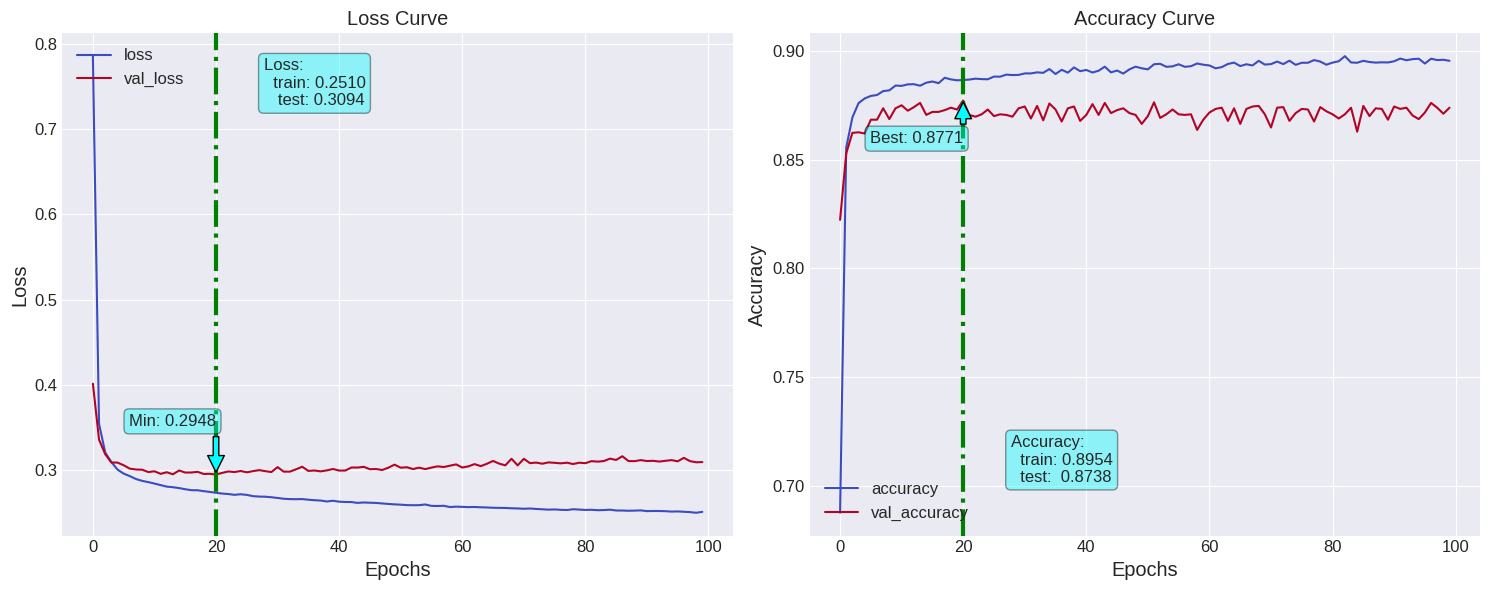

In [ ]:
fn_plot_tf_hist(loss_df)

In [ ]:
loss_df[loss_df['val_loss'] == loss_df['val_loss'].min()]

,accuracy,loss,val_accuracy,val_loss
20,0.886547,0.273319,0.877135,0.29479


## Feature Importance 

In [ ]:
for layer in model.layers:
    if isinstance(layer, tf.keras.layers.Dense):
        first_layer = layer
        break
    
# Get weights and biases
weights = first_layer.get_weights()[0]  # Shape: (33, 18)
biases = first_layer.get_weights()[1]   # Shape: (18,)
feature_importance = np.abs(weights).mean(axis=1)

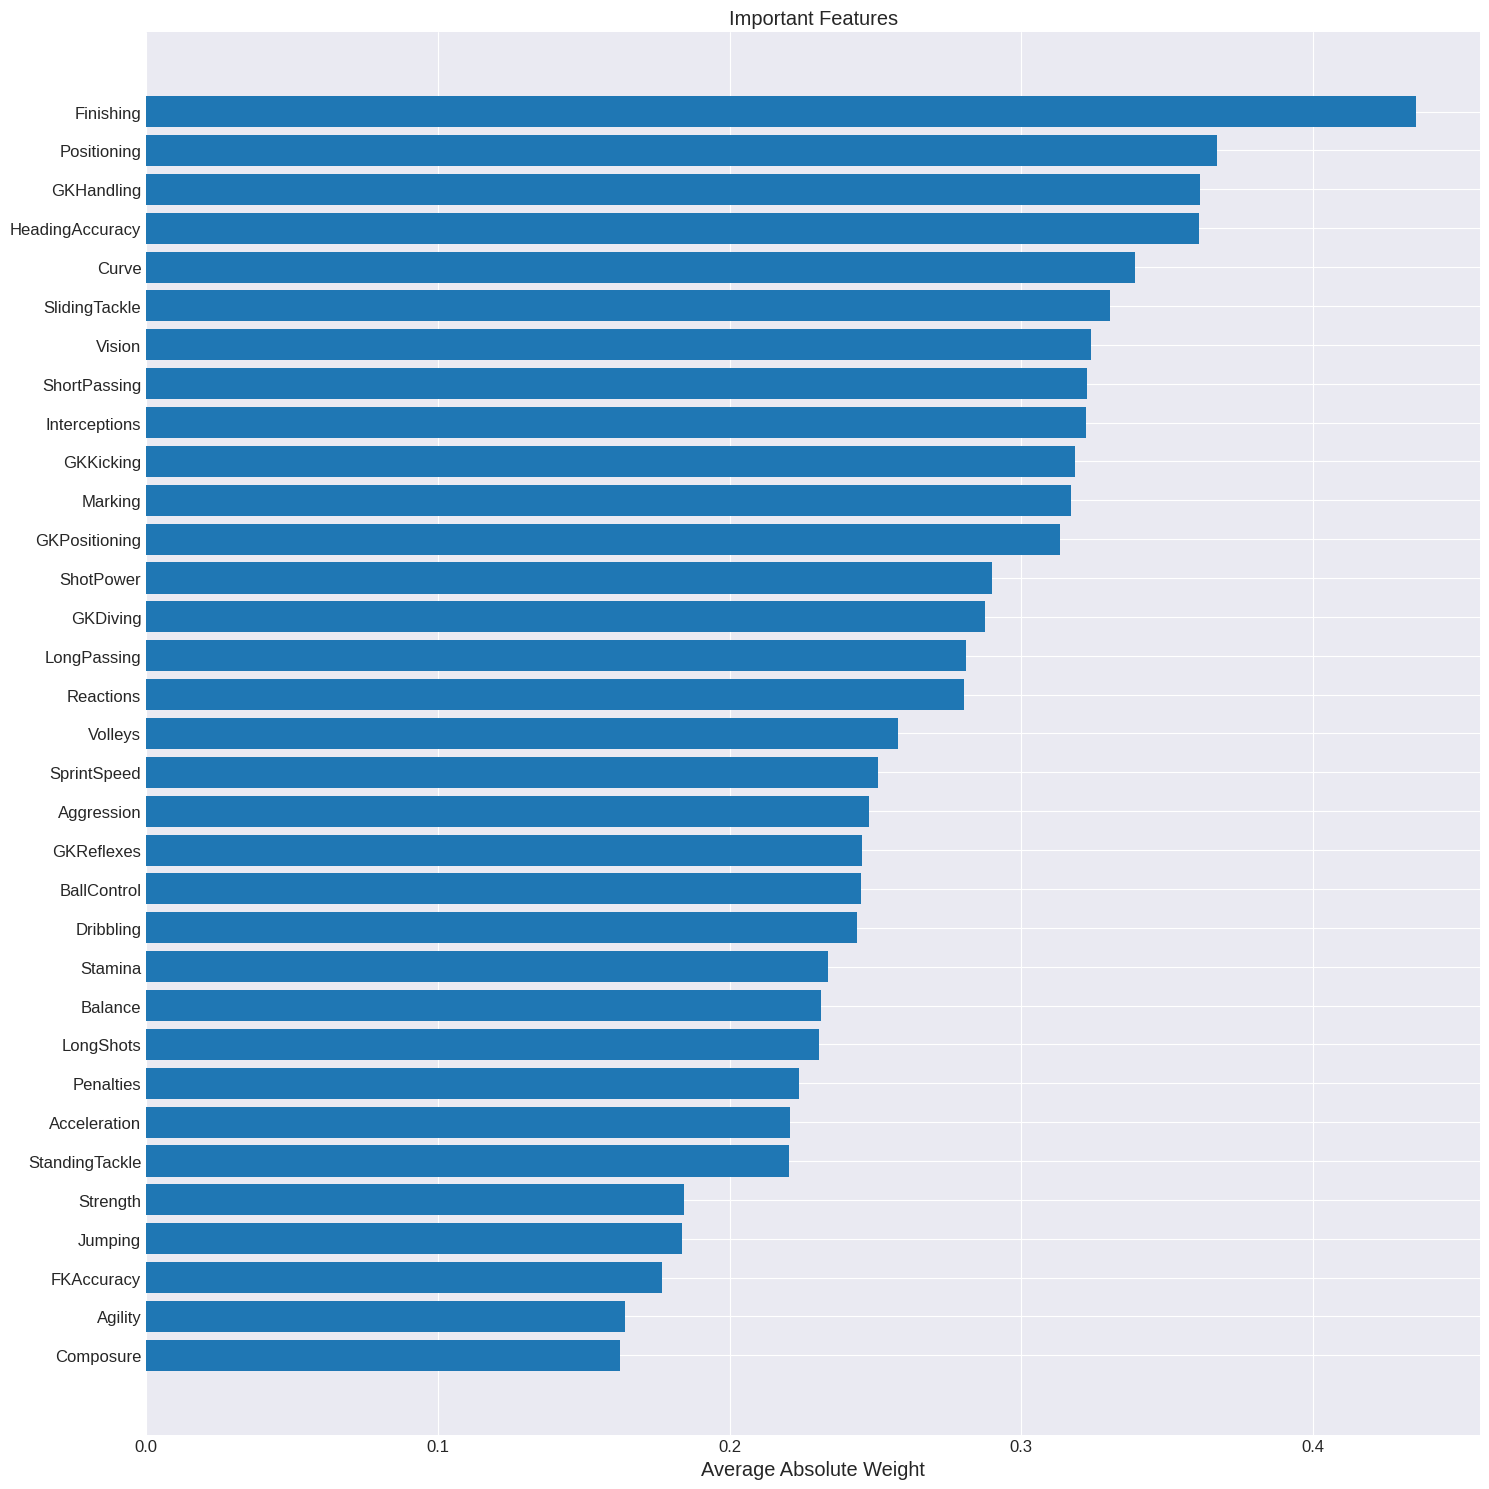

In [ ]:
feature_names = data_df.columns[1:-1] # Exclude 'Position' and 'Position_encoded'

top_features = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots() # figsize=(10, 6)
ax.barh(top_features['feature'], top_features['importance'])
ax.set_xlabel('Average Absolute Weight')
ax.set_title('Important Features')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Predictions - Train Data

In [ ]:
probability_model = tf.keras.Sequential([
  model,
  tf.keras.layers.Softmax()
])

In [ ]:
def fn_plot_confusion_matrix(y_true, y_pred, labels):
    '''
    Args:
        y_true: Ground Truth 
        y_pred : Predictions
        labels : dictonary 
                  {0: 'Goal Keeper', 
                  1: 'Defender', 
                  2: 'Mid-Fielder', 
                  3: 'Forward'}
    
    '''
    
    cm  = confusion_matrix(y_true, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=labels.values())
    
    fig, ax = plt.subplots(figsize = (4,4))
    
    disp.plot(ax = ax, cmap = 'Blues', xticks_rotation = 'vertical', colorbar=False)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    ax.set_title(f'Confusion Matrix (Macro F1: {f1_macro:.3f})', fontsize=12)
    # Disable the grid
    ax.grid(False)

    plt.show()

In [ ]:
y_true, y_pred = [],[]
for feats, lbls in train_ds:
    pred = probability_model(feats).numpy()
    pred = pred.argmax(axis =1)
    y_pred.extend(pred)
    y_true.extend(lbls)
print('Accuracy score on Test Data :{:.5f}'.format(accuracy_score(y_true,y_pred)))

Accuracy score on Test Data :0.89784


In [ ]:
print(classification_report( y_true, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1620
           1       0.93      0.94      0.93      4693
           2       0.85      0.89      0.87      5470
           3       0.88      0.79      0.83      2734

    accuracy                           0.90     14517
   macro avg       0.91      0.90      0.91     14517
weighted avg       0.90      0.90      0.90     14517



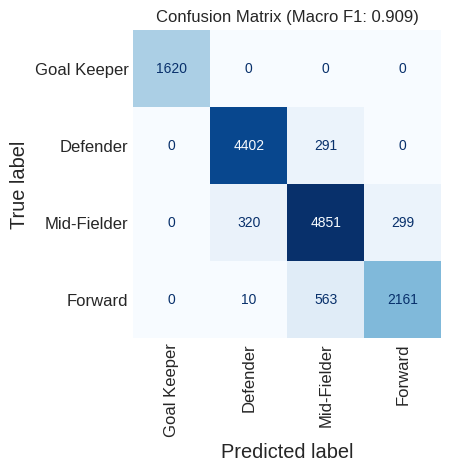

In [ ]:
fn_plot_confusion_matrix( y_true, y_pred, labels=class_labels)

## Predictions - Test Data

In [ ]:
y_true, y_pred = [],[]
for feats, lbls in test_ds:
    pred = probability_model(feats).numpy()
    pred = pred.argmax(axis =1)
    y_pred.extend(pred)
    y_true.extend(lbls)
len(y_pred), len(y_true)

print('Accuracy score on Test Data :{:.5f}'.format(accuracy_score(y_true,y_pred)))

Accuracy score on Test Data :0.87383


In [ ]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       405
           1       0.92      0.93      0.92      1173
           2       0.82      0.86      0.84      1368
           3       0.84      0.73      0.78       684

    accuracy                           0.87      3630
   macro avg       0.89      0.88      0.89      3630
weighted avg       0.87      0.87      0.87      3630



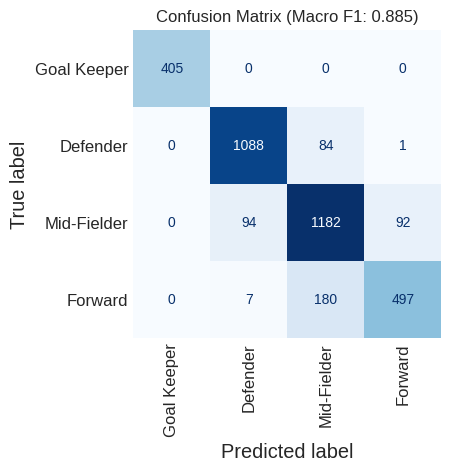

In [ ]:
fn_plot_confusion_matrix( y_true, y_pred, labels=class_labels)